# Satellite Orbit Tracking Demo

Rocket launches from Earth's surface, enters a circular orbit at ~1.5 R_earth,
and is tracked by EKF and UKF using noisy radar measurements (range + bearing)
from a ground station.

This notebook generates the satellite tracking animation shown in the README.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from kalman.extended import ExtendedKalmanFilter
from kalman.unscented import UnscentedKalmanFilter
from kalman.gaussian import GaussianState

torch.manual_seed(42)
np.random.seed(42)

mu = 1.0          # gravitational parameter (normalized)
target_r = 1.5    # target orbit radius [R_earth]
dt_l = 0.06       # launch timestep
dt_o = 0.04       # orbit timestep


## 1. Launch trajectory (parametric spiral from surface to orbit)

In [2]:
T_launch = 50
t_launch = np.linspace(0, 1, T_launch)
r_launch = 1.01 + (target_r - 1.01) * (3*t_launch**2 - 2*t_launch**3)
theta_launch = t_launch * np.pi * 0.6

launch_x = r_launch * np.cos(theta_launch)
launch_y = r_launch * np.sin(theta_launch)
launch_vx = np.gradient(launch_x, dt_l)
launch_vy = np.gradient(launch_y, dt_l)
launch_states = np.stack([launch_x, launch_y, launch_vx, launch_vy], axis=-1)

print(f"Launch end: r = {r_launch[-1]:.3f} R_earth, altitude ~ {(r_launch[-1]-1)*6371:.0f} km")


Launch end: r = 1.500 R_earth, altitude ~ 3186 km


## 2. Orbital phase (Keplerian two-body dynamics)

In [3]:
T_orbit = 350

def rk4(s, dt):
    def rhs(s):
        x, y, vx, vy = s
        r = np.sqrt(x**2 + y**2)
        return np.array([vx, vy, -mu*x/r**3, -mu*y/r**3])
    k1 = rhs(s); k2 = rhs(s + 0.5*dt*k1)
    k3 = rhs(s + 0.5*dt*k2); k4 = rhs(s + dt*k3)
    return s + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

# Inject into circular orbit
inj = launch_states[-1].copy()
r_inj = np.sqrt(inj[0]**2 + inj[1]**2)
v_circ = np.sqrt(mu / r_inj)
theta_inj = np.arctan2(inj[1], inj[0])
inj[2] = -v_circ * np.sin(theta_inj)
inj[3] = v_circ * np.cos(theta_inj)

orbit_states = np.zeros((T_orbit, 4))
orbit_states[0] = inj
for t in range(1, T_orbit):
    orbit_states[t] = rk4(orbit_states[t-1], dt_o)

all_states = np.concatenate([launch_states, orbit_states])
T_total = len(all_states)

print(f"Orbit radius: {r_inj:.3f} R_earth")
print(f"Total timesteps: {T_total} (launch: {T_launch}, orbit: {T_orbit})")


Orbit radius: 1.500 R_earth
Total timesteps: 400 (launch: 50, orbit: 350)


## 3. Noisy radar observations

In [4]:
station = np.array([1.0, 0.0])
r_noise, b_noise = 0.005, 0.01

obs = np.zeros((T_total, 2))
for t in range(T_total):
    dx, dy = all_states[t, 0] - station[0], all_states[t, 1] - station[1]
    obs[t] = [np.sqrt(dx**2 + dy**2), np.arctan2(dy, dx)]
    obs[t] += np.array([r_noise, b_noise]) * np.random.randn(2)


## 4. EKF and UKF tracking

In [5]:
station_t = torch.tensor(station, dtype=torch.float64)
Q_launch = torch.eye(4, dtype=torch.float64) * 0.001
Q_orbit = torch.eye(4, dtype=torch.float64) * 1e-5
R = torch.diag(torch.tensor([r_noise**2, b_noise**2], dtype=torch.float64))

def f_orb(state):
    def rhs(s):
        x, y, vx, vy = s[...,0], s[...,1], s[...,2], s[...,3]
        r = torch.sqrt(x**2 + y**2)
        return torch.stack([vx, vy, -mu*x/r**3, -mu*y/r**3], dim=-1)
    k1 = rhs(state); k2 = rhs(state + 0.5*dt_o*k1)
    k3 = rhs(state + 0.5*dt_o*k2); k4 = rhs(state + dt_o*k3)
    return state + (dt_o/6)*(k1 + 2*k2 + 2*k3 + k4)

def h_rad(state):
    dx, dy = state[...,0] - station_t[0], state[...,1] - station_t[1]
    return torch.stack([torch.sqrt(dx**2 + dy**2), torch.atan2(dy, dx)], dim=-1)

def F_jac(state):
    eps = 1e-6
    J = torch.zeros(*state.shape[:-1], 4, 4, dtype=state.dtype)
    f0 = f_orb(state)
    for i in range(4):
        e = torch.zeros_like(state); e[..., i] = eps
        J[..., :, i] = (f_orb(state + e) - f0) / eps
    return J

def H_jac(state):
    dx, dy = state[...,0] - station_t[0], state[...,1] - station_t[1]
    r2 = dx**2 + dy**2; r = torch.sqrt(r2)
    J = torch.zeros(*state.shape[:-1], 2, 4, dtype=state.dtype)
    J[...,0,0] = dx/r; J[...,0,1] = dy/r; J[...,1,0] = -dy/r2; J[...,1,1] = dx/r2
    return J

obs_t = torch.tensor(obs, dtype=torch.float64)
init_mean = torch.tensor([1.01, 0.0, 0.0, 0.3], dtype=torch.float64)
init_cov = torch.diag(torch.tensor([0.01, 0.01, 0.05, 0.05], dtype=torch.float64))

# EKF
ekf = ExtendedKalmanFilter(4, 2, f_orb, h_rad, F_jacobian=F_jac, H_jacobian=H_jac, Q=Q_launch, R=R, eps=1e-10)
state = GaussianState(init_mean.clone(), init_cov.clone())
ekf_m = []
for t in range(T_total):
    if t == T_launch:
        ekf._Q_spd._L.data = torch.linalg.cholesky(Q_orbit)
    state = ekf.predict(state)
    state = ekf.update(state, obs_t[t])
    ekf_m.append(state.mean.detach().numpy())
ekf_m = np.array(ekf_m)

# UKF
ukf = UnscentedKalmanFilter(4, 2, f_orb, h_rad, alpha=1e-3, beta=2.0, kappa=0.0, Q=Q_launch, R=R)
state = GaussianState(init_mean.clone(), init_cov.clone())
ukf_m = []
for t in range(T_total):
    if t == T_launch:
        ukf._Q_spd._L.data = torch.linalg.cholesky(Q_orbit)
    state = ukf.predict(state)
    state = ukf.update(state, obs_t[t])
    ukf_m.append(state.mean.detach().numpy())
ukf_m = np.array(ukf_m)

ekf_rmse = np.sqrt(np.mean((ekf_m[:,:2] - all_states[:,:2])**2))
ukf_rmse = np.sqrt(np.mean((ukf_m[:,:2] - all_states[:,:2])**2))
print(f"EKF RMSE: {ekf_rmse:.5f}")
print(f"UKF RMSE: {ukf_rmse:.5f}")


EKF RMSE: 0.00506
UKF RMSE: 0.00515


## 5. Visualization

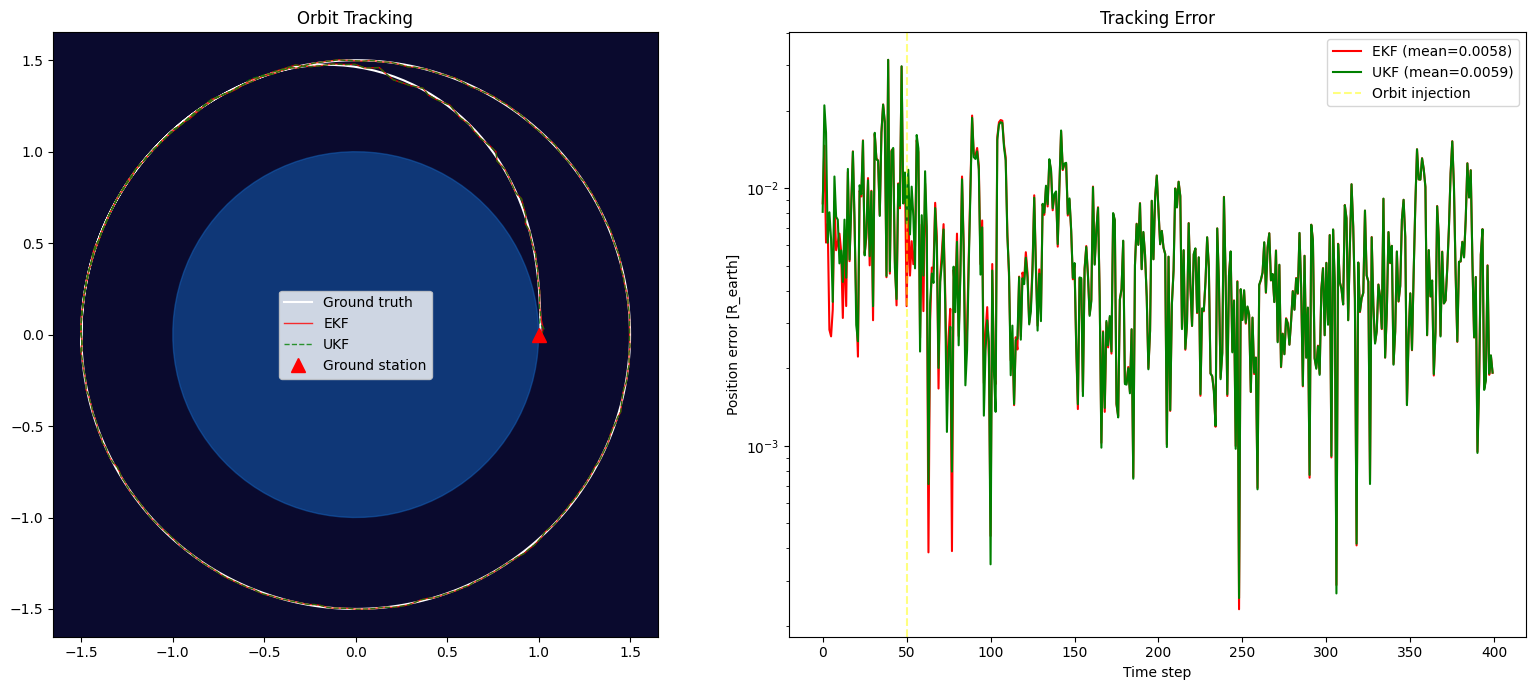

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
theta_e = np.linspace(0, 2*np.pi, 100)
ax.fill(np.cos(theta_e), np.sin(theta_e), color='#1565C0', alpha=0.5)
ax.plot(all_states[:,0], all_states[:,1], 'w-', lw=1.5, label='Ground truth')
ax.plot(ekf_m[:,0], ekf_m[:,1], 'r-', lw=1, alpha=0.8, label='EKF')
ax.plot(ukf_m[:,0], ukf_m[:,1], 'g--', lw=1, alpha=0.8, label='UKF')
ax.plot(*station, 'r^', ms=10, label='Ground station')
ax.set_aspect('equal'); ax.legend(); ax.set_title('Orbit Tracking')
ax.set_facecolor('#0a0a2e')

ax = axes[1]
ekf_err = np.sqrt(np.sum((ekf_m[:,:2] - all_states[:,:2])**2, axis=1))
ukf_err = np.sqrt(np.sum((ukf_m[:,:2] - all_states[:,:2])**2, axis=1))
ax.plot(ekf_err, 'r-', label=f'EKF (mean={ekf_err.mean():.4f})')
ax.plot(ukf_err, 'g-', label=f'UKF (mean={ukf_err.mean():.4f})')
ax.axvline(x=T_launch, color='yellow', ls='--', alpha=0.5, label='Orbit injection')
ax.set_xlabel('Time step'); ax.set_ylabel('Position error [R_earth]')
ax.set_title('Tracking Error'); ax.legend(); ax.set_yscale('log')
plt.tight_layout(); plt.show()
